In [1]:
!pip install ultralytics ensemble-boxes -q
print("✅ Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00
✅ Done


In [2]:
import os

source_path = "/kaggle/input/datasets/abcxyzi/raddet-icassp-2025/"

!rm -rf /kaggle/working/nist512_data
!mkdir -p /kaggle/working/nist512_data

print("Extracting NIST512 parts...")
!cat {source_path}NISTSpecMaxHold512Data.tar.part-a* | tar -xf - -C /kaggle/working/nist512_data/

print("\nExtraction complete. Contents:")
!ls -F /kaggle/working/nist512_data/

Extracting NIST512 parts...

Extraction complete. Contents:
NISTSpecMaxHold512Data/


In [ ]:
import os, yaml
from pathlib import Path

base_dir = None
for root, dirs, files in os.walk('/kaggle/working/nist512_data'):
    if 'images' in dirs and os.path.exists(os.path.join(root, 'images', 'train')):
        base_dir = root
        break

if not base_dir:
    raise RuntimeError("❌ Dataset root not found. Check Cell 2 output.")

print(f"✅ Dataset root: {base_dir}")

val_subdir = 'valid' if os.path.exists(os.path.join(base_dir, 'images', 'valid')) else 'val'
print(f"   Val folder: images/{val_subdir}")

config = {
    'path': base_dir,
    'train': 'images/train',
    'val':   f'images/{val_subdir}',
    'names': {0:'P0N#1', 1:'P0N#2', 2:'Q3N#1', 3:'Q3N#2', 4:'Q3N#3'}
}
with open('/kaggle/working/nist512.yaml', 'w') as f:
    yaml.dump(config, f)
print("✅ YAML written: /kaggle/working/nist512.yaml")

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def find_label(img_path: Path) -> Path | None:
    parts = img_path.parts
    for i, part in enumerate(parts):
        if part == 'images':
            lbl = Path(*parts[:i]) / 'labels' / Path(*parts[i+1:]).with_suffix('.txt')
            return lbl if lbl.exists() else None
    return None

all_images, all_labels = [], []

splits_to_check = ['train', val_subdir, 'test']
for split in splits_to_check:
    img_dir = Path(base_dir) / 'images' / split
    if not img_dir.exists():
        print(f"  [{split}] not found — skipping")
        continue
    imgs = sorted([p for p in img_dir.rglob('*') if p.suffix.lower() in IMG_EXTS])
    pairs = [(i, find_label(i)) for i in imgs]
    pairs = [(i, l) for i, l in pairs if l is not None]
    print(f"  [{split}] {len(pairs)} image-label pairs")
    all_images += [p[0] for p in pairs]
    all_labels += [p[1] for p in pairs]

CLASS_NAMES = {0:'P0N#1', 1:'P0N#2', 2:'Q3N#1', 3:'Q3N#2', 4:'Q3N#3'}
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\n✅ Total: {len(all_images)} images across all splits")

✅ Dataset root: /kaggle/working/nist512_data/NISTSpecMaxHold512Data
   Val folder: images/val
✅ YAML written: /kaggle/working/nist512.yaml
  [train] 6973 image-label pairs
  [val] 3027 image-label pairs
  [test] 10000 image-label pairs

✅ Total: 20000 images across all splits


In [ ]:
import torch
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

YOLO_PT  = '/kaggle/input/datasets/air001/yolov8s/yolov8s_best.pt'
TRANS_PT = '/kaggle/input/datasets/air001/transformer/transformer_best.pt'

print("\nLoading YOLOv8s...")
yolo_model  = YOLO(YOLO_PT)
print(f"  ✅ YOLOv8s  — type: {type(yolo_model.model).__name__}  classes: {yolo_model.names}")

print("Loading Transformer (RT-DETR)...")
trans_model = YOLO(TRANS_PT)
print(f"  ✅ RT-DETR  — type: {type(trans_model.model).__name__}  classes: {trans_model.names}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda

Loading YOLOv8s...
  ✅ YOLOv8s  — type: DetectionModel  classes: {0: 'P0N#1', 1: 'P0N#2', 2: 'Q3N#1', 3: 'Q3N#2', 4: 'Q3N#3'}
Loading Transformer (RT-DETR)...
  ✅ RT-DETR  — type: RTDETRDetectionModel  classes: {0: 'P0N#1', 1: 'P0N#2', 2: 'Q3N#1', 3: 'Q3N#2', 4: 'Q3N#3'}


In [ ]:
import numpy as np
from ensemble_boxes import weighted_boxes_fusion
from tqdm.notebook import tqdm

# ── WBF settings ─────────────────────────────────────────────────────────
IMG_SIZE     = 512
CONF_THRESH  = 0.25
IOU_THRESH   = 0.55
SKIP_BOX_THR = 0.01
WBF_WEIGHTS  = [1, 1]  

def predict_one(model, img_path, conf=CONF_THRESH):
    """Run one model → return WBF-ready (boxes_norm, scores, labels)."""
    result = model.predict(
        source=str(img_path),
        imgsz=IMG_SIZE,
        conf=conf,
        device=DEVICE,
        verbose=False,
    )[0]

    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return np.zeros((0,4)), np.zeros(0), np.zeros(0, dtype=int)

    h, w   = result.orig_shape
    xyxy_n = boxes.xyxy.cpu().numpy() / np.array([w, h, w, h])
    xyxy_n = np.clip(xyxy_n, 0, 1)
    scores = boxes.conf.cpu().numpy()
    labels = boxes.cls.cpu().numpy().astype(int)
    return xyxy_n, scores, labels


def ensemble_predict(img_path):
    """WBF fusion of both models on one image."""
    boxes_list, scores_list, labels_list = [], [], []
    for model in [yolo_model, trans_model]:
        b, s, l = predict_one(model, img_path)
        boxes_list.append(b.tolist())
        scores_list.append(s.tolist())
        labels_list.append(l.tolist())

    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        weights=WBF_WEIGHTS,
        iou_thr=IOU_THRESH,
        skip_box_thr=SKIP_BOX_THR,
    )
    return boxes, scores, labels.astype(int)


all_predictions = []
for img_path in tqdm(all_images, desc='WBF Ensemble Inference'):
    boxes, scores, labels = ensemble_predict(img_path)
    all_predictions.append({
        'img_path': img_path,
        'boxes'   : boxes,
        'scores'  : scores,
        'labels'  : labels,
    })

print(f"\n✅ Inference done on {len(all_predictions)} images")

WBF Ensemble Inference:   0%|          | 0/20000 [00:00<?, ?it/s]


✅ Inference done on 20000 images


In [ ]:
import pandas as pd

def load_gt_yolo(label_path):
    """Returns list of (cls, x1, y1, x2, y2) — all normalised."""
    boxes = []
    if not label_path or not Path(label_path).exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = max(0.0, cx - bw/2)
            y1 = max(0.0, cy - bh/2)
            x2 = min(1.0, cx + bw/2)
            y2 = min(1.0, cy + bh/2)
            boxes.append((cls, x1, y1, x2, y2))
    return boxes

def box_iou(b1, b2):
    x1 = max(b1[0], b2[0]); y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2]); y2 = min(b1[3], b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter/union if union > 0 else 0.0

IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05).round(2)   # [0.50, 0.55, …, 0.95]
detections = {t: {c: [] for c in range(NUM_CLASSES)} for t in IOU_THRESHOLDS}
gt_counts  = {c: 0 for c in range(NUM_CLASSES)}

for pred, lbl_path in zip(all_predictions, all_labels):
    gt_boxes = load_gt_yolo(lbl_path)
    for (cls, *_) in gt_boxes:
        gt_counts[cls] += 1

    pred_boxes  = pred['boxes']
    pred_scores = pred['scores']
    pred_labels = pred['labels']

    for iou_thr in IOU_THRESHOLDS:
        matched_gt = set()
        order = np.argsort(-pred_scores) if len(pred_scores) else []

        for idx in order:
            pb = pred_boxes[idx]
            pc = pred_labels[idx]
            ps = pred_scores[idx]

            best_iou, best_gi = 0.0, -1
            for gi, (gc, *gb) in enumerate(gt_boxes):
                if gc != pc or gi in matched_gt:
                    continue
                iou = box_iou(pb, gb)
                if iou > best_iou:
                    best_iou, best_gi = iou, gi

            is_tp = int(best_iou >= iou_thr)
            if is_tp:
                matched_gt.add(best_gi)
            detections[iou_thr][pc].append((ps, is_tp))

print("✅ TP/FP matching done")

def compute_ap(dets, n_gt):
    if n_gt == 0 or len(dets) == 0:
        return 0.0
    dets  = sorted(dets, key=lambda x: -x[0])
    tp    = np.cumsum([d[1] for d in dets], dtype=float)
    fp    = np.cumsum([1-d[1] for d in dets], dtype=float)
    rec   = tp / n_gt
    prec  = tp / (tp + fp)
    ap = 0.0
    for thr in np.linspace(0, 1, 101):
        ap += (prec[rec >= thr].max() if any(rec >= thr) else 0.0) / 101
    return ap

class_ap = {c: [compute_ap(detections[t][c], gt_counts[c]) for t in IOU_THRESHOLDS]
            for c in range(NUM_CLASSES)}

map50    = float(np.mean([class_ap[c][0]       for c in range(NUM_CLASSES)]))
map50_95 = float(np.mean([np.mean(class_ap[c]) for c in range(NUM_CLASSES)]))

def prf(cls, iou_thr=0.50):
    dets = detections[iou_thr][cls]
    n_gt = gt_counts[cls]
    if not dets:
        return 0.0, 0.0, 0.0
    tp = sum(d[1] for d in dets)
    fp = len(dets) - tp
    fn = n_gt - tp
    p  = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    r  = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0.0
    return p, r, f1

rows = []
for c in range(NUM_CLASSES):
    p, r, f1 = prf(c)
    rows.append({
        'Class'    : CLASS_NAMES[c],
        'GT Boxes' : gt_counts[c],
        'Precision': round(p, 4),
        'Recall'   : round(r, 4),
        'F1'       : round(f1, 4),
        'AP@50'    : round(class_ap[c][0], 4),
        'AP@50-95' : round(float(np.mean(class_ap[c])), 4),
    })

p_all, r_all, f1_all = zip(*[prf(c) for c in range(NUM_CLASSES)])
rows.append({
    'Class'    : '★ OVERALL',
    'GT Boxes' : sum(gt_counts.values()),
    'Precision': round(float(np.mean(p_all)),  4),
    'Recall'   : round(float(np.mean(r_all)),  4),
    'F1'       : round(float(np.mean(f1_all)), 4),
    'AP@50'    : round(map50,    4),
    'AP@50-95' : round(map50_95, 4),
})

df = pd.DataFrame(rows)
print("\n" + "="*65)
print("     WBF ENSEMBLE — FINAL PERFORMANCE  (YOLOv8s + RT-DETR)")
print("="*65)
print(df.to_string(index=False))
print("="*65)
print(f"  mAP@50    : {map50:.4f}  ({map50*100:.2f}%)")
print(f"  mAP@50-95 : {map50_95:.4f}  ({map50_95*100:.2f}%)")
print("="*65)

✅ TP/FP matching done

     WBF ENSEMBLE — FINAL PERFORMANCE  (YOLOv8s + RT-DETR)
    Class  GT Boxes  Precision  Recall     F1  AP@50  AP@50-95
    P0N#1      4000     0.9398  0.8387 0.8864 0.8306    0.6491
    P0N#2      4000     0.9118  0.9980 0.9530 0.9899    0.8049
    Q3N#1      4000     0.9913  0.9998 0.9955 0.9901    0.9292
    Q3N#2      4000     0.8945  0.9245 0.9093 0.9172    0.5934
    Q3N#3      4000     0.9980  0.9998 0.9989 0.9901    0.9434
★ OVERALL     20000     0.9471  0.9521 0.9486 0.9436    0.7840
  mAP@50    : 0.9436  (94.36%)
  mAP@50-95 : 0.7840  (78.40%)


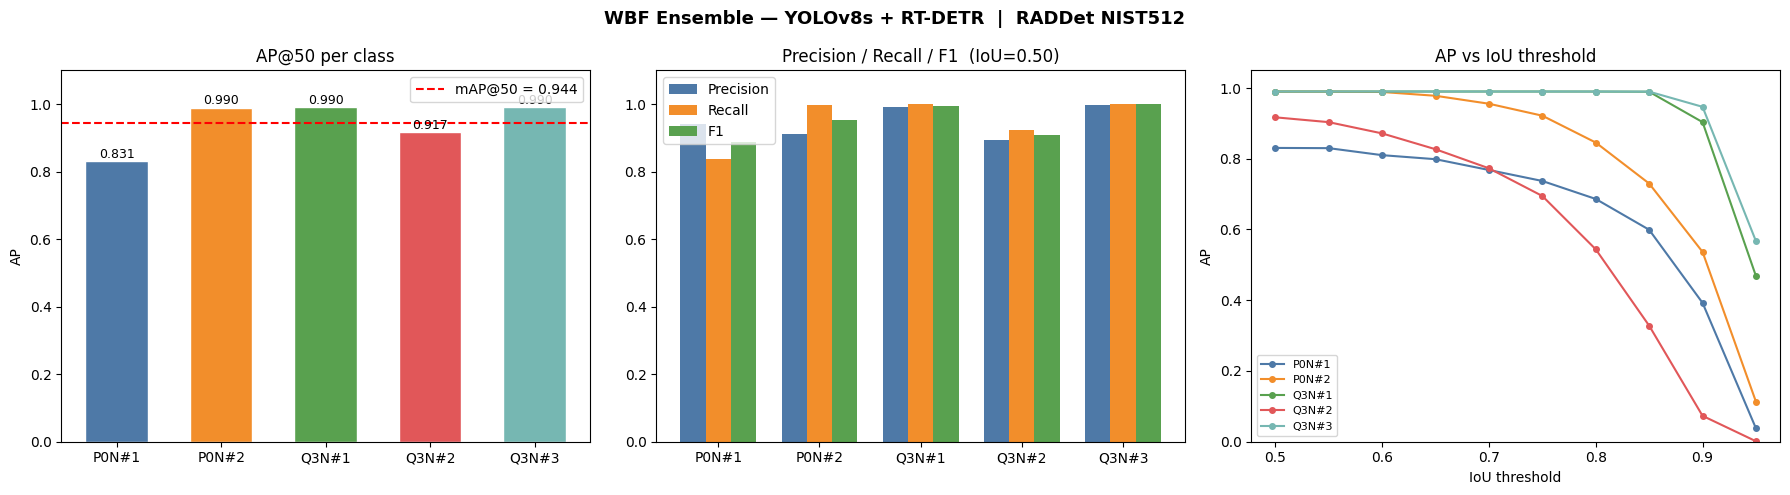

✅ Saved: /kaggle/working/ensemble_results.png
✅ Saved: /kaggle/working/ensemble_metrics.csv


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('WBF Ensemble — YOLOv8s + RT-DETR  |  RADDet NIST512',
             fontsize=13, fontweight='bold')

COLORS = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2']
cls_labels = [CLASS_NAMES[c] for c in range(NUM_CLASSES)]

ax = axes[0]
ap50_vals = [class_ap[c][0] for c in range(NUM_CLASSES)]
bars = ax.bar(cls_labels, ap50_vals, color=COLORS, edgecolor='white', width=0.6)
ax.axhline(map50, color='red', linestyle='--', lw=1.5, label=f'mAP@50 = {map50:.3f}')
for bar, v in zip(bars, ap50_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.set_title('AP@50 per class')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AP')
ax.legend()

ax = axes[1]
x  = np.arange(NUM_CLASSES)
w  = 0.25
p_v  = [prf(c)[0] for c in range(NUM_CLASSES)]
r_v  = [prf(c)[1] for c in range(NUM_CLASSES)]
f1_v = [prf(c)[2] for c in range(NUM_CLASSES)]
ax.bar(x-w, p_v,  width=w, label='Precision', color='#4e79a7')
ax.bar(x,   r_v,  width=w, label='Recall',    color='#f28e2b')
ax.bar(x+w, f1_v, width=w, label='F1',        color='#59a14f')
ax.set_xticks(x); ax.set_xticklabels(cls_labels)
ax.set_title('Precision / Recall / F1  (IoU=0.50)')
ax.set_ylim(0, 1.1); ax.legend()

ax = axes[2]
for c in range(NUM_CLASSES):
    ax.plot(IOU_THRESHOLDS, class_ap[c], marker='o', markersize=4,
            label=CLASS_NAMES[c], color=COLORS[c])
ax.set_title('AP vs IoU threshold')
ax.set_xlabel('IoU threshold')
ax.set_ylabel('AP')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/ensemble_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save CSV ──────────────────────────────────────────────────────────────
df.to_csv('/kaggle/working/ensemble_metrics.csv', index=False)
print("✅ Saved: /kaggle/working/ensemble_results.png")
print("✅ Saved: /kaggle/working/ensemble_metrics.csv")